<a href="https://colab.research.google.com/github/Govind-2004/Case_Study_Preprocessing/blob/main/Assesment_2_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Libraries

In [205]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from statistics import mode

#scaling numerical data
from sklearn.preprocessing import MinMaxScaler

# mutual information library
from sklearn.feature_selection import mutual_info_classif

#encoding non numerical columns
from sklearn.preprocessing import OneHotEncoder

# for train test split we have to import the method from scikit learn
from sklearn.model_selection import train_test_split

# for linear regression model
from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# for evaluation
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score



#Load and Explore Dataset

In [206]:
filepath = '/content/drive/MyDrive/Colab Notebooks/Datasets /heart_disease.csv'
df_hd = pd.read_csv(filepath)
df_hd

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [207]:
df_hd.isnull().sum() # No null values

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


#EDA

In [208]:
df_hd.shape

(1025, 14)

In [209]:
df_hd.size

14350

In [210]:
df_hd.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [211]:
df_hd.info()

# all features are numerical

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


##Histogram

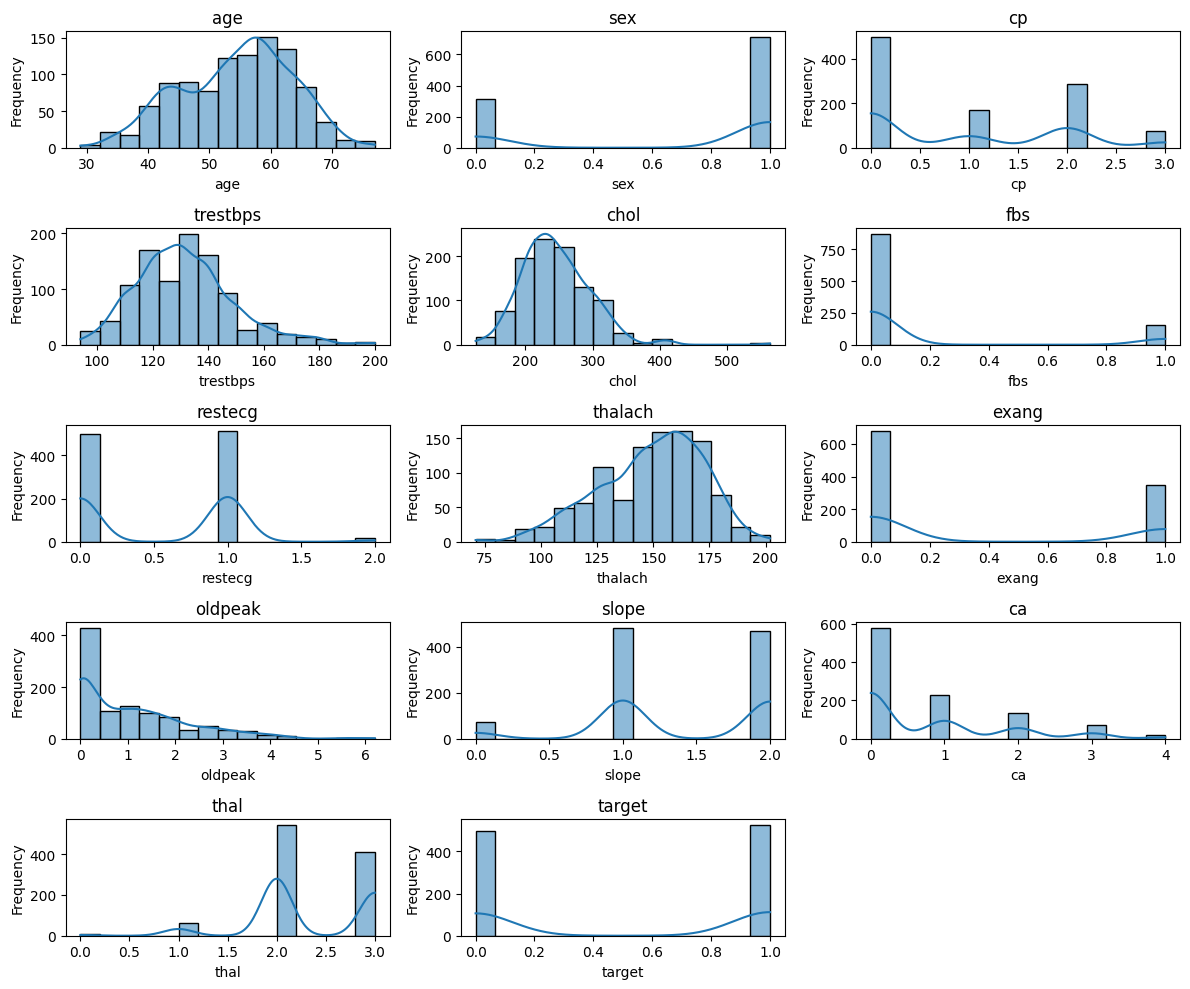

In [212]:
# Plotting histogram for each numerical columns

plt.figure(figsize=(12,10))

for i, col in enumerate(df_hd.columns, 1):
    plt.subplot(5,3, i)
    sns.histplot(df_hd[col], bins=15, kde=True)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [213]:
# Checking skewness

for i, col in enumerate(df_hd.columns,1):
  print(f'skew_{col}: {df_hd[col].skew()}')

skew_age: -0.24886590174584555
skew_sex: -0.8514488985126767
skew_cp: 0.5294552058584099
skew_trestbps: 0.739768226050074
skew_chol: 1.0740727783354815
skew_fbs: 1.9713385276901942
skew_restecg: 0.18044041112923528
skew_thalach: -0.5137771771417209
skew_exang: 0.692655170469321
skew_oldpeak: 1.2108993882065326
skew_slope: -0.4791344197425813
skew_ca: 1.2611886429097716
skew_thal: -0.5243897710407986
skew_target: -0.05277848219047285


In [214]:
# All the features are skewed
# Therefore if scaling need to be done use MinMax Scaling

##Correlation

In [215]:
cor_mat = df_hd.corr()
cor_mat

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.103240,-0.071966,0.271121,0.219823,0.121243,-0.132696,-0.390227,0.088163,0.208137,-0.169105,0.271551,0.072297,-0.229324
sex,-0.103240,1.000000,-0.041119,-0.078974,-0.198258,0.027200,-0.055117,-0.049365,0.139157,0.084687,-0.026666,0.111729,0.198424,-0.279501
cp,-0.071966,-0.041119,1.000000,0.038177,-0.081641,0.079294,0.043581,0.306839,-0.401513,-0.174733,0.131633,-0.176206,-0.163341,0.434854
trestbps,0.271121,-0.078974,0.038177,1.000000,0.127977,0.181767,-0.123794,-0.039264,0.061197,0.187434,-0.120445,0.104554,0.059276,-0.138772
chol,0.219823,-0.198258,-0.081641,0.127977,1.000000,0.026917,-0.147410,-0.021772,0.067382,0.064880,-0.014248,0.074259,0.100244,-0.099966
fbs,0.121243,0.027200,0.079294,0.181767,0.026917,1.000000,-0.104051,-0.008866,0.049261,0.010859,-0.061902,0.137156,-0.042177,-0.041164
restecg,-0.132696,-0.055117,0.043581,-0.123794,-0.147410,-0.104051,1.000000,0.048411,-0.065606,-0.050114,0.086086,-0.078072,-0.020504,0.134468
thalach,-0.390227,-0.049365,0.306839,-0.039264,-0.021772,-0.008866,0.048411,1.000000,-0.380281,-0.349796,0.395308,-0.207888,-0.098068,0.422895
exang,0.088163,0.139157,-0.401513,0.061197,0.067382,0.049261,-0.065606,-0.380281,1.000000,0.310844,-0.267335,0.107849,0.197201,-0.438029
oldpeak,0.208137,0.084687,-0.174733,0.187434,0.064880,0.010859,-0.050114,-0.349796,0.310844,1.000000,-0.575189,0.221816,0.202672,-0.438441


<Axes: >

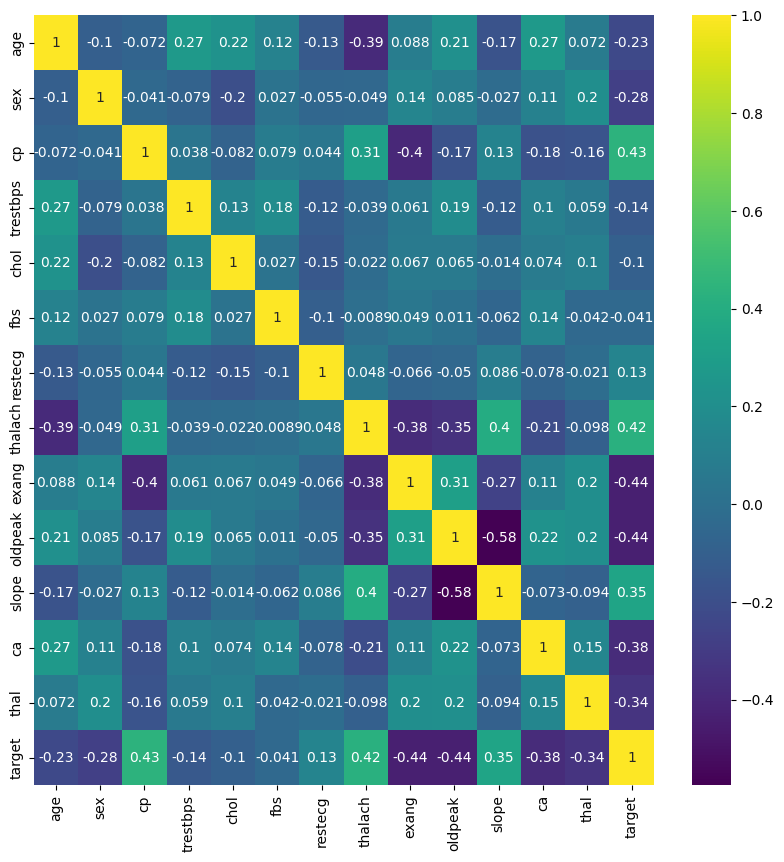

In [216]:
# Heatmap
plt.figure(figsize = (10,10))
sns.heatmap(cor_mat, cmap = 'viridis', annot = True)

#Preprocessing

##Data Cleaning

### Duplicate Handling

In [217]:
df_hd.duplicated().sum()
df_hd.drop_duplicates(inplace = True)  # Duplicates are dropped since no unique ID is present

In [218]:
df_hd.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


###Boxplot

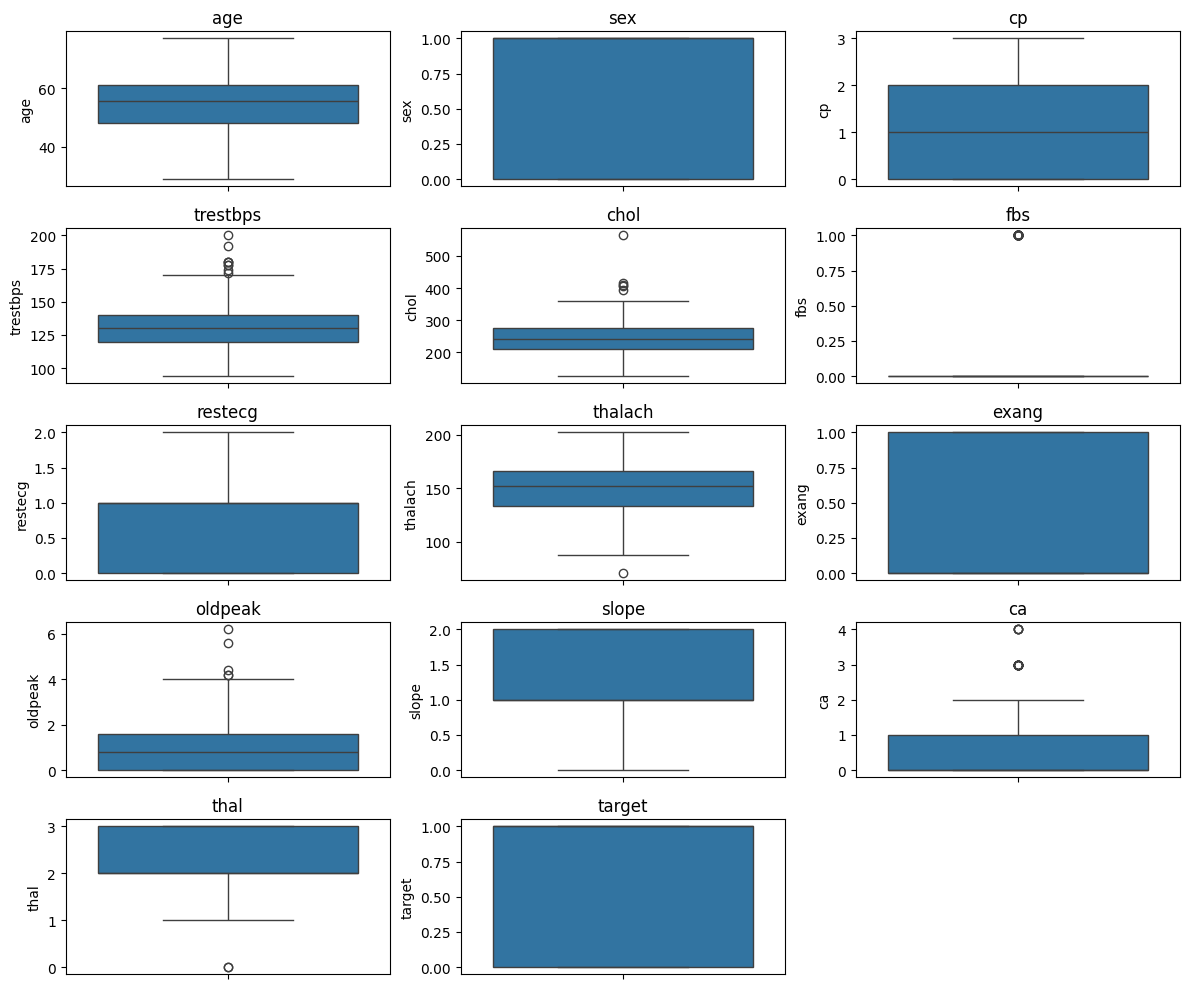

In [219]:
# Plotting boxplot for each  columns

# Boxplot Before Handling Outliers

plt.figure(figsize=(12,10))

for i, col in enumerate(df_hd.columns, 1):
    plt.subplot(5,3, i)
    sns.boxplot(df_hd[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [220]:
# Outlier Handling
clip_cols = df_hd.columns
clip_cols
#IQR method
def clipping(columns):
   Q1 = df_hd[columns].quantile(.25)
   Q3 = df_hd[columns].quantile(.75)
   IQR = Q3 - Q1
   lower_bound = Q1 - (1.5 * IQR)
   upper_bound = Q3 + (1.5 * IQR)

   df_hd[columns] = np.clip(df_hd[columns], lower_bound, upper_bound)
for columns in clip_cols:
  clipping(columns)



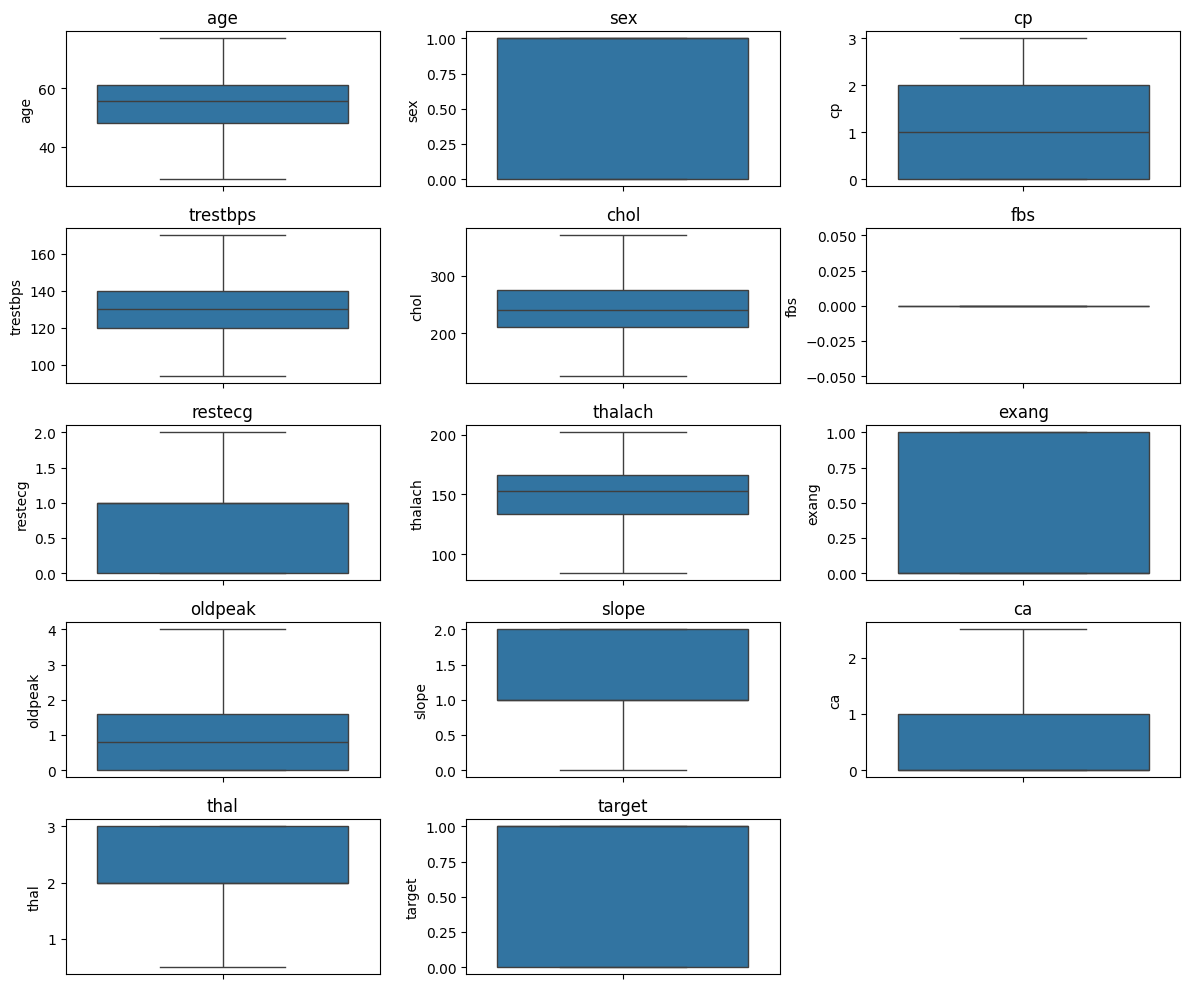

In [221]:
# Plotting boxplot for each  columns

# Boxplot After Handling Outliers

plt.figure(figsize=(12,10))

for i, col in enumerate(df_hd.columns, 1):
    plt.subplot(5,3, i)
    sns.boxplot(df_hd[col])
    plt.title(col)
plt.tight_layout()
plt.show()

## Data Transforming

In [222]:
df_hd.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212.0,0,1,168.0,0,1.0,2,2.0,3.0,0
1,53,1,0,140,203.0,0,0,155.0,1,3.1,0,0.0,3.0,0
2,70,1,0,145,174.0,0,1,125.0,1,2.6,0,0.0,3.0,0
3,61,1,0,148,203.0,0,1,161.0,0,0.0,2,1.0,3.0,0
4,62,0,0,138,294.0,0,1,106.0,0,1.9,1,2.5,2.0,0


### Encoding



In [223]:
# No need of LAbel Encoding since already done

In [224]:
# One hot encoding

one_hot = OneHotEncoder(sparse_output=False)
# Transform
encoded_data = one_hot.fit_transform(df_hd[['cp', 'restecg', 'thal']])
# Convert to Dataframe
encoded_df = pd.DataFrame(encoded_data, columns = one_hot.get_feature_names_out(['cp', 'restecg', 'thal']),index = df_hd.index)
# drop cols
df_hd.drop(columns = ['cp', 'restecg', 'thal'] )
# Concatenate with encode data
df_hd = pd.concat([df_hd, encoded_df], axis = 1)
df_hd.head(3)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,...,cp_1,cp_2,cp_3,restecg_0,restecg_1,restecg_2,thal_0.5,thal_1.0,thal_2.0,thal_3.0
0,52,1,0,125,212.0,0,1,168.0,0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,53,1,0,140,203.0,0,0,155.0,1,3.1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,70,1,0,145,174.0,0,1,125.0,1,2.6,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [225]:
# Splitting Data since target is 'target'

X = df_hd.drop('target', axis = 1)
y = df_hd['target']

In [226]:
X

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,...,cp_1,cp_2,cp_3,restecg_0,restecg_1,restecg_2,thal_0.5,thal_1.0,thal_2.0,thal_3.0
0,52,1,0,125,212.0,0,1,168.0,0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,53,1,0,140,203.0,0,0,155.0,1,3.1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,70,1,0,145,174.0,0,1,125.0,1,2.6,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,61,1,0,148,203.0,0,1,161.0,0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,62,0,0,138,294.0,0,1,106.0,0,1.9,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,68,0,2,120,211.0,0,0,115.0,0,1.5,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
733,44,0,2,108,141.0,0,1,175.0,0,0.6,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
739,52,1,0,128,255.0,0,1,161.0,1,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
843,59,1,3,160,273.0,0,0,125.0,0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [227]:
y

,target
0,0
1,0
2,0
3,0
4,0
...,...
723,1
733,1
739,0
843,0


###Scaling

In [228]:
# Before Scaling
df_hd.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,...,cp_1,cp_2,cp_3,restecg_0,restecg_1,restecg_2,thal_0.5,thal_1.0,thal_2.0,thal_3.0
0,52,1,0,125,212.0,0,1,168.0,0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,53,1,0,140,203.0,0,0,155.0,1,3.1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,70,1,0,145,174.0,0,1,125.0,1,2.6,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,61,1,0,148,203.0,0,1,161.0,0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,62,0,0,138,294.0,0,1,106.0,0,1.9,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [229]:
df_hd.info()

<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 0 to 878
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        302 non-null    int64  
 1   sex        302 non-null    int64  
 2   cp         302 non-null    int64  
 3   trestbps   302 non-null    int64  
 4   chol       302 non-null    float64
 5   fbs        302 non-null    int64  
 6   restecg    302 non-null    int64  
 7   thalach    302 non-null    float64
 8   exang      302 non-null    int64  
 9   oldpeak    302 non-null    float64
 10  slope      302 non-null    int64  
 11  ca         302 non-null    float64
 12  thal       302 non-null    float64
 13  target     302 non-null    int64  
 14  cp_0       302 non-null    float64
 15  cp_1       302 non-null    float64
 16  cp_2       302 non-null    float64
 17  cp_3       302 non-null    float64
 18  restecg_0  302 non-null    float64
 19  restecg_1  302 non-null    float64
 20  restecg_2  302 

In [230]:
# Scale features [resting blood pressure, serum cholesterol, maximum heart rate, and oldpeak] using MinMaxScaler.

MM_scaler = MinMaxScaler()
skew_cols = ['trestbps','chol','oldpeak','thalach']

X[skew_cols] = MM_scaler.fit_transform(X[skew_cols])

In [231]:
X.head() # After Scaling

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,...,cp_1,cp_2,cp_3,restecg_0,restecg_1,restecg_2,thal_0.5,thal_1.0,thal_2.0,thal_3.0
0,52,1,0,0.407895,0.351918,0,1,0.711559,0,0.250,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,53,1,0,0.605263,0.315090,0,0,0.601273,1,0.775,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,70,1,0,0.671053,0.196419,0,1,0.346766,1,0.650,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,61,1,0,0.710526,0.315090,0,1,0.652174,0,0.000,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,62,0,0,0.578947,0.687468,0,1,0.185578,0,0.475,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


##Mutual Information_Classification

In [232]:
# mutual information of each column in 'X' with respect to 'y'

mi = mutual_info_classif(X, y)

# converting into a dataframe
mi_X = pd.DataFrame({'Features' : X.columns, 'mutual Information':mi})
mi_X

,Features,mutual Information
0,age,0.000000
1,sex,0.018659
2,cp,0.143870
3,trestbps,0.001533
4,chol,0.063902
5,fbs,0.065138
6,restecg,0.019974
7,thalach,0.088831
8,exang,0.039696
9,oldpeak,0.104119


##

#Train Test Split

In [237]:
X_train, X_test, y_train, y_test =  train_test_split(X, y, test_size = 0.2, random_state=12)

#Model Building

## Logistic Regression

In [238]:
# create model object
log_reg = LogisticRegression()

# Train the model
log_reg.fit(X_train, y_train)

# predictions using the model
y_pred_log_reg = log_reg.predict(X_test)

# Evaluate model preformance
acc_log_reg = accuracy_score(y_test, y_pred_log_reg)
prec_log_reg = precision_score(y_test, y_pred_log_reg)
recall_log_reg = recall_score(y_test, y_pred_log_reg)
F1score_log_reg = f1_score(y_test, y_pred_log_reg)



print('Log Accuracy is :', acc_log_reg)
print('Log precsion is :', prec_log_reg)
print('Log recall is :', recall_log_reg)
print('Log f1_score is :', F1score_log_reg)

Log Accuracy is : 0.8524590163934426
Log precsion is : 0.8529411764705882
Log recall is : 0.8787878787878788
Log f1_score is : 0.8656716417910447


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


##KNN

In [239]:
# create model object
Knn_class = KNeighborsClassifier()

# Train the model
Knn_class.fit(X_train, y_train)

# predictions using the model
y_pred_Knn_class = Knn_class.predict(X_test)

# Evaluate model preformance
acc_Knn_class = accuracy_score(y_test, y_pred_Knn_class)
prec_Knn_class = precision_score(y_test, y_pred_Knn_class)
recall_Knn_class = recall_score(y_test, y_pred_Knn_class)
F1score_Knn_class = f1_score(y_test, y_pred_Knn_class)



print('Knn Accuracy is :', acc_Knn_class)
print('Knn precsion is :', prec_Knn_class)
print('Knn recall is :', recall_Knn_class)
print('Knn f1_score is :', F1score_Knn_class)

Knn Accuracy is : 0.7868852459016393
Knn precsion is : 0.7631578947368421
Knn recall is : 0.8787878787878788
Knn f1_score is : 0.8169014084507042


##Random Forest

In [240]:
# create model object
random_forest = RandomForestClassifier()

# Train the model
random_forest.fit(X_train, y_train)

# predictions using the model
y_pred_random_forest = random_forest.predict(X_test)

# Evaluate model preformance
acc_random_forest= accuracy_score(y_test, y_pred_random_forest)
prec_random_forest = precision_score(y_test, y_pred_random_forest)
recall_random_forest = recall_score(y_test, y_pred_random_forest)
F1score_random_forest = f1_score(y_test, y_pred_random_forest)



print('Knn Accuracy is :', acc_random_forest)
print('Knn precsion is :', prec_random_forest)
print('Knn recall is :', recall_random_forest)
print('Knn f1_score is :', F1score_random_forest)

Knn Accuracy is : 0.8032786885245902
Knn precsion is : 0.8
Knn recall is : 0.8484848484848485
Knn f1_score is : 0.8235294117647058


###